In [5]:
import numpy as np
import matplotlib.pylab as pl
import ot
import ot.plot
from ot.datasets import make_1D_gauss as gauss

In [2]:
# Generate data
n = 50
x = np.arange(n, dtype=np.float64)

# Gaussian distribution
a = 0.6 * gauss(n, m=15, s=5) + 0.4 * gauss(n, m=35, s=5)
b = gauss(n, m=25, s=5)

# loss matrix
M = ot.dist(x.reshape((n, 1)), x.reshape((n, 1)))
M /= M.max()

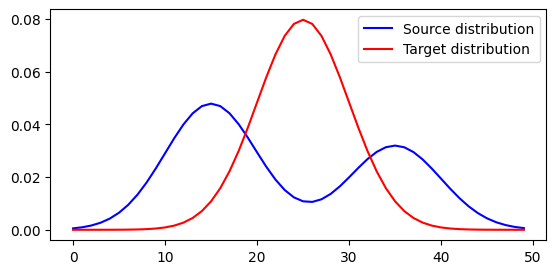

In [4]:
# Plot distribution and loss matrix

pl.figure(1, figsize=(6.4, 3))
pl.plot(x, a, "b", label="Source distribution")
pl.plot(x, b, "r", label="Target distribution")
pl.legend()

(<Axes: >, <Axes: >, <Axes: >)

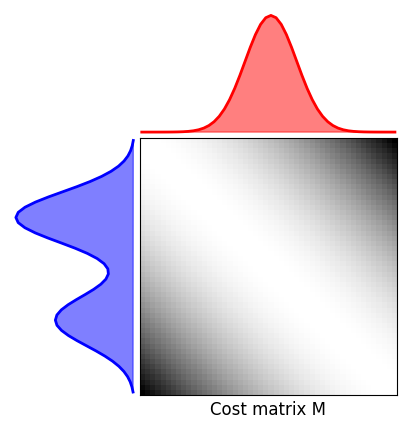

In [6]:
pl.figure(2, figsize=(5, 5))
ot.plot.plot1D_mat(a, b, M, "Cost matrix M")

## Define Group lasso regularization and gradient

In [8]:
def reg_gl(G):
  G1 = G[: n // 2, :] ** 2
  G2 = G[n // 2 :, :] ** 2
  gl1 = np.sum(np.sqrt(np.sum(G1, 0)))
  gl2 = np.sum(np.sqrt(np.sum(G2, 0)))
  return gl1 + gl2 + 0.1 * np.sum(G**2)

def grad_gl(G):
  G1 = G[: n // 2, :]
  G2 = G[n // 2 :, :]
  gl1 = G1 / np.sqrt(np.sum(G1**2, 0, keepdims=True) + 1e-8)
  gl2 = G2 / np.sqrt(np.sum(G2**2, 0, keepdims=True) + 1e-8)
  return np.concatenate((gl1, gl2), axis=0) + 0.2 * G

reg_type_gl = (reg_gl, grad_gl)